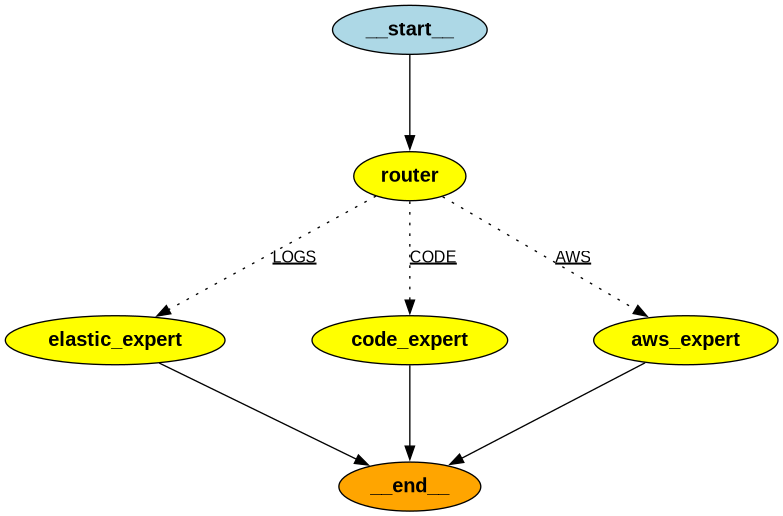

In [1]:
from IPython.display import Image, display
import sys
import os
import sqlite3
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, END
from typing import TypedDict
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool
from pydantic.v1 import BaseModel, Field
from elasticsearch8 import Elasticsearch
from typing import Dict, List, Any

load_dotenv()
if not os.environ.get("ANTHROPIC_API_KEY"):
    print("environment variable ANTHROPIC_API_KEY not set")
    sys.exit(1)

ES_API_KEY = os.environ.get("ES_API_KEY", None)
ES_USER = os.environ.get("ES_USER", None)
ES_PASSWORD = os.environ.get("ES_PASSWORD", None)

# Custom state for agent


class MultiAgentState(TypedDict):
    question: HumanMessage
    question_type: str
    answer: str
    feedback: str


question_category_prompt = '''You are an information security incident manager. Your task is to classify the incoming questions.
Depending on your answer, question will be routed to the right team, so your task is crucial for our team.
There are 3 possible question types:
- LOGS - questions related to logs stored in Elastic
- AWS - questions related to AWS configuration
- CODE - questions related to code analysis

This is IMPORTANT You must only return either LOGS, GRC or CODE.
'''


def router_node(state: MultiAgentState):
    messages = [
        SystemMessage(content=question_category_prompt),
        HumanMessage(content=state['question'])
    ]
    model = ChatAnthropic(model="claude-3-5-sonnet-latest")
    response = model.invoke(messages)
    return {"question_type": response.content}


def elastic_audit_lookup(messagedata):
    "searches elastic audit logs for a match on a query"
    try:
        hosts = [{"host": "127.0.0.1", "port": int("9200"), "scheme": "https"}]
        es = Elasticsearch(
            hosts,
            api_key=ES_API_KEY,
            verify_certs=False,
            headers={
                "Accept": "application/vnd.elasticsearch+json;compatible-with=8",
                "Content-Type": "application/vnd.elasticsearch+json;compatible-with=8"
            })

        es_query = {"bool": {"filter": []}}
        es_query["bool"]["filter"].append(messagedata)
        time_range = {"range": {"@timestamp": {}}}
        time_range["range"]["@timestamp"]["gte"] = "now-7d"
        time_range["range"]["@timestamp"]["lte"] = "now"
        es_query["bool"]["filter"].append(time_range)

        if not es_query["bool"]["filter"]:
            es_query = {"match_all": {}}

        response = es.search(
            index=["go-audit*", "ssh", "journactl", "web_server"],
            body={
                "query": es_query,
                "size": 50,
                "_source": ["messages.data", "@timestamp"],
                "sort": [{"@timestamp": {"order": "desc"}}]
            }
        )

        return (response)

    except Exception as e:
        return (f"Failed to initialize Elasticsearch client: {str(e)}")


def elastic_ioc_lookup(ioc):
    "Searches all indices and fields for a specific IP address"
    try:
        hosts = [{"host": "127.0.0.1", "port": 9200, "scheme": "https"}]
        es = Elasticsearch(
            hosts,
            api_key=ES_API_KEY,
            verify_certs=False,
            headers={
                "Accept": "application/vnd.elasticsearch+json;compatible-with=8",
                "Content-Type": "application/vnd.elasticsearch+json;compatible-with=8"
            }
        )

        es_query = {
            "bool": {
                "must": [
                    {
                        "query_string": {
                            "query": f"\"{ioc}\"",
                            "fields": ["*"]
                        }
                    }
                ],
                "filter": [
                    {
                        "range": {
                            "@timestamp": {
                                "gte": "now-7d",
                                "lte": "now"
                            }
                        }
                    }
                ]
            }
        }

        response = es.search(
            index="_all",
            body={
                "query": es_query,
                "size": 50,
                "_source": ["message", "messages.data", "@timestamp"],
                "sort": [{"@timestamp": {"order": "desc"}}]
            }
        )

        return (response)

    except Exception as e:
        return f"Failed to initialize Elasticsearch client: {str(e)}"


class ElasticQuery(BaseModel):
    query: str = Field(description="Elastic query to run")


@tool(args_schema=ElasticQuery)
def execute_elastic_audit_query(query: str) -> str:
    """Searches messages.data for audit log events.
    queries should be in the following form {"messages.data": "<insert_search_term_here>"}
    """
    return elastic_audit_lookup(query)


@tool(args_schema=ElasticQuery)
def execute_elastic_ioc_query(query: str) -> str:
    """Runs a search across all elastic logs for specific IOC. The IOC must be a single string"""
    return elastic_ioc_lookup(query)


elastic_expert_system_prompt = '''You are an expert SOC analyst and are proficient at using
Elastic to search data and understand security alerts and incidents.

You have two tools at your disposal:
1. execute_elastic_ioc_query - this accepts a single string for IOC, e.g. an IP address, a hash, a filename and runs a search across all logs
2. execute_elastic_query - this accepts a query in the format {"messages.data": "<insert_search_term_here>"}.

Use your expertise to pick the correct tool for the job.
'''


def elastic_expert_node(state: MultiAgentState):
    model = ChatAnthropic(model="claude-3-5-sonnet-latest")
    elastic_agent = create_react_agent(model,
                                       [execute_elastic_audit_query,
                                           execute_elastic_ioc_query],
                                       checkpointer=memory,
                                       state_modifier=elastic_expert_system_prompt)
    messages = [HumanMessage(content=state['question'])]
    result = elastic_agent.invoke({"messages": messages})
    return {'answer': result['messages'][-1].content}


aws_expert_system_prompt = ''''''


def aws_expert_node(state: MultiAgentState):
    model = ChatAnthropic(model="claude-3-5-sonnet-latest")
    elastic_agent = create_react_agent(model,
                                       [execute_aws_query],
                                       checkpointer=memory,
                                       state_modifier=aws_expert_system_prompt)
    messages = [HumanMessage(content=state['question'])]
    result = elastic_agent.invoke({"messages": messages})
    return {'answer': result['messages'][-1].content}


code_analysis_expert_system_prompt = ''''''


def code_analysis_expert_node(state: MultiAgentState):
    model = ChatAnthropic(model="claude-3-5-sonnet-latest")
    elastic_agent = create_react_agent(model,
                                       [execute_code_query],
                                       checkpointer=memory,
                                       state_modifier=code_analysis_expert_system_prompt)
    messages = [HumanMessage(content=state['question'])]
    result = elastic_agent.invoke({"messages": messages})
    return {'answer': result['messages'][-1].content}


def route_question(state: MultiAgentState):
    return state['question_type']


# Create the SQLite saver correctly
conn = sqlite3.connect(':memory:', check_same_thread=False)
memory = SqliteSaver(conn)

# Build the graph
builder = StateGraph(MultiAgentState)
builder.add_node("router", router_node)
builder.add_node('elastic_expert', elastic_expert_node)
builder.add_node('code_expert', code_analysis_expert_node)
builder.add_node('aws_expert', aws_expert_node)
builder.add_conditional_edges(
    "router",
    route_question,
    {'LOGS': 'elastic_expert',
     'CODE': 'code_expert',
     'AWS': 'aws_expert'}
)


builder.set_entry_point("router")
builder.add_edge('elastic_expert', END)
builder.add_edge('code_expert', END)
builder.add_edge('aws_expert', END)
graph = builder.compile(checkpointer=memory)

Image(graph.get_graph().draw_png())

# Now questions

In [3]:

# Test with different questions
# Threads are used to separate conversations
thread = {"configurable": {"thread_id": "1"}}
question = "We have a security alert for IP 18.171.55.110. Investigate logs for this IP"
results = []

for s in graph.stream({'question': question,}, thread, stream_mode="updates"):
    results.append(s)
print(results[-1]['elastic_expert']['answer'])

{'router': {'question_type': 'LOGS'}}


/home/george/git/AITalk/LLMAnalyse/LLMAnalyse/lib64/python3.12/site-packages/elasticsearch8/_sync/client/__init__.py:403: SecurityWarning: Connecting to 'https://127.0.0.1:9200' using TLS with verify_certs=False is insecure
  _transport = transport_class(
/home/george/git/AITalk/LLMAnalyse/LLMAnalyse/lib64/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'elastic_expert': {'answer': 'Based on the logs, I can provide a detailed analysis of the activity associated with IP 18.171.55.110. There are several concerning patterns:\n\n1. Web Application Attacks (Around 08:37):\n- The IP attempted command injection through the web application:\n  - First legitimate request: "GET /ping?host=127.0.0.1"\n  - Followed by command injection attempts:\n    - "GET /ping?host=127.0.0.1%3b+ls+-la"\n    - "GET /ping?host=127.0.0.1%3b+cat+ssh.pem"\n  This shows attempts to execute system commands and access SSH keys.\n\n2. SSH Authentication Attempts:\n- 07:55:07: Failed SSH authentication attempt for user "ec2-user"\n- 08:38:05: Failed SSH attempt with invalid username "ecs_user"\n- 08:38:15: Successful SSH login as "ec2-user" using public key authentication\n- 08:38:30: SSH session disconnected\n\nThe sequence suggests:\n1. Initial reconnaissance through web application\n2. Attempted command injection to gather system information and SSH keys\n3. Failed 